<a href="https://colab.research.google.com/github/HebaRouk/-Build-a-ML-Workflow-For-Scones-Unlimited-On-Amazon-SageMaker/blob/main/CV701_lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CV701 Lab 4: Image Enhancement and Edge Detection


## Demo

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Plot the histogram of pixel intensities

(575, 476) uint8


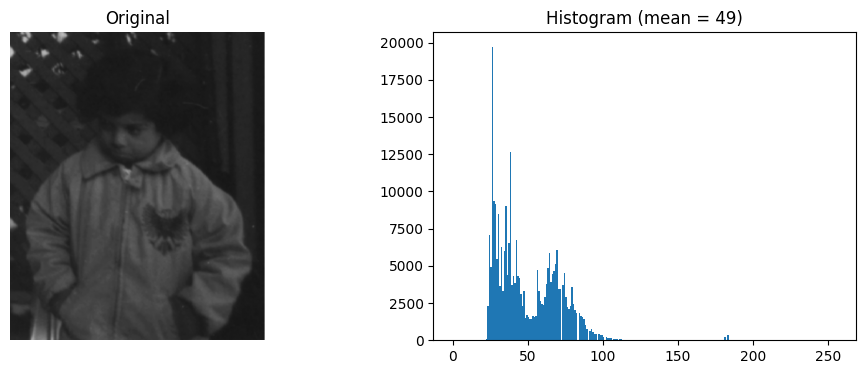

In [2]:
# example2.png is a grayscale image stored as RGBA, so read it as a single channel
img = cv2.imread("./example2.png", cv2.IMREAD_GRAYSCALE)
print(img.shape, img.dtype)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].hist(img.ravel(), bins=256, range=(0, 256))
axes[1].set_title(f"Histogram (mean = {img.mean():.0f})")
plt.show()

# Gamma correction

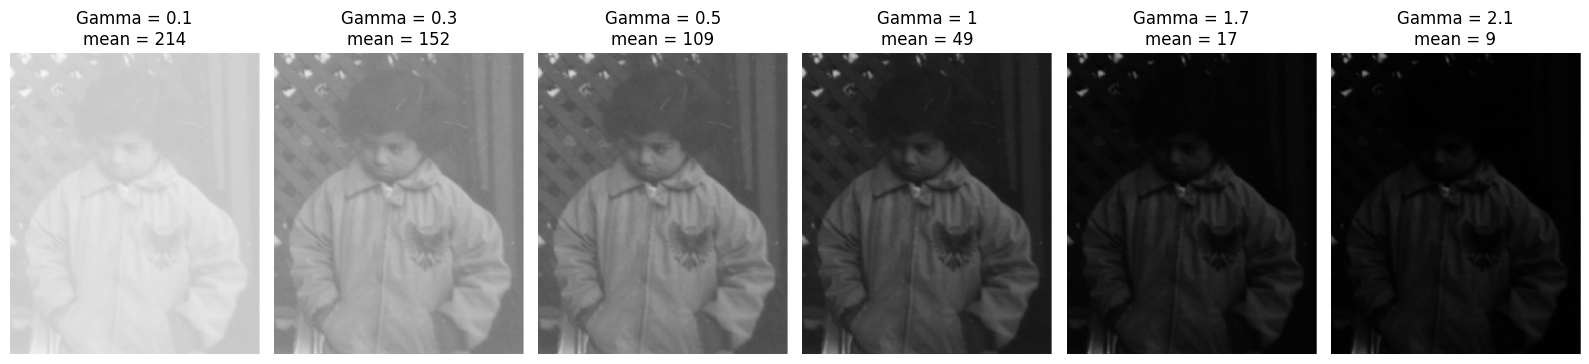

In [3]:
def gamma_correction(img, gamma=1.0):
    """
    Applies s = r^gamma on the normalised [0, 1] range.
    gamma < 1 brightens the image, gamma > 1 darkens it.
    """
    img_norm = img / 255.0
    img_gamma = np.power(img_norm, gamma)
    return (img_gamma * 255).astype(np.uint8)


gamma_values = [0.1, 0.3, 0.5, 1, 1.7, 2.1]
gamma_corrected_images = [gamma_correction(img, g) for g in gamma_values]

fig, ax = plt.subplots(1, len(gamma_values), figsize=(16, 4))
for i, g in enumerate(gamma_values):
    ax[i].imshow(gamma_corrected_images[i], cmap="gray", vmin=0, vmax=255)
    ax[i].set_title(f"Gamma = {g}\nmean = {gamma_corrected_images[i].mean():.0f}")
    ax[i].axis("off")
plt.tight_layout()
plt.show()

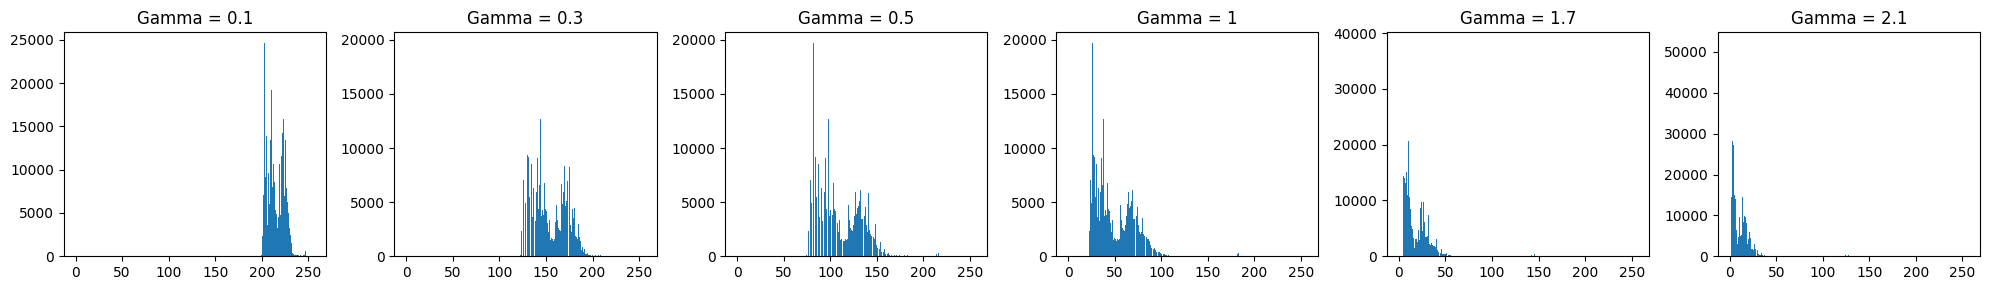

In [4]:
fig, ax = plt.subplots(1, len(gamma_values), figsize=(20, 3))
for i, g in enumerate(gamma_values):
    ax[i].hist(gamma_corrected_images[i].ravel(), bins=256, range=(0, 256))
    ax[i].set_title(f"Gamma = {g}")
plt.tight_layout()
plt.show()

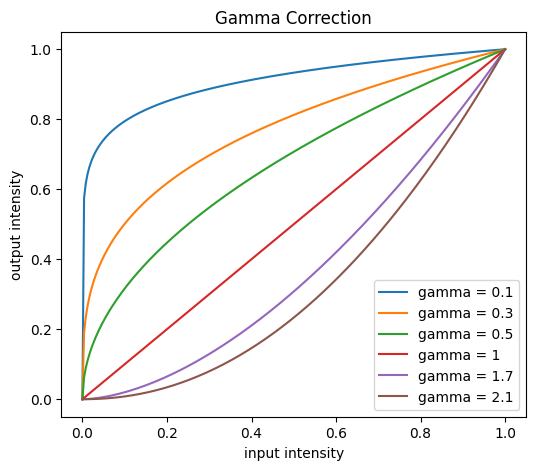

In [5]:
# The transformation curves themselves
x = np.arange(0, 256) / 255.0

fig, ax = plt.subplots(figsize=(6, 5))
for g in gamma_values:
    ax.plot(x, np.power(x, g), label=f"gamma = {g}")
ax.set_xlabel("input intensity")
ax.set_ylabel("output intensity")
ax.set_title("Gamma Correction")
ax.legend()
plt.show()

# Canny edge detection

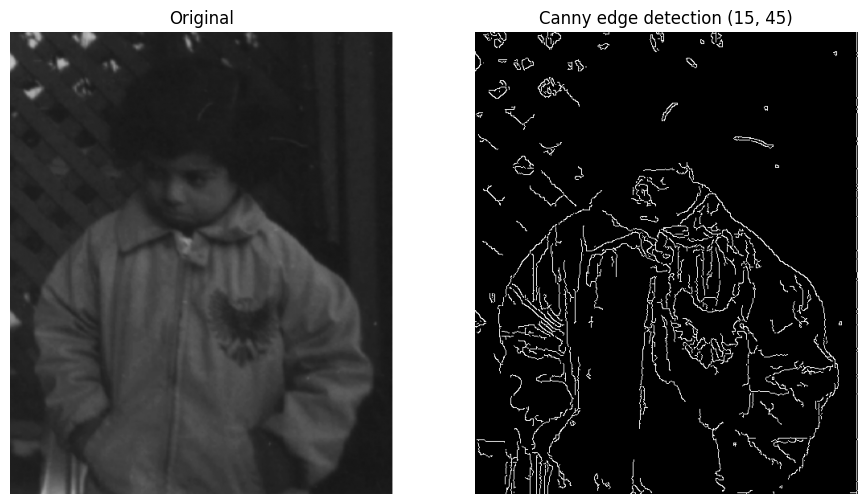

In [6]:
# cv2.Canny(image, threshold1, threshold2, apertureSize=3, L2gradient=False)
canny_image = cv2.Canny(img, 15, 45)

fig, ax = plt.subplots(1, 2, figsize=(11, 6))
ax[0].imshow(img, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original")
ax[1].imshow(canny_image, cmap="gray")
ax[1].set_title("Canny edge detection (15, 45)")
for a in ax:
    a.axis("off")
plt.show()

# Lab Activities

## 1. Histogram of pixel intensities
Plot the histogram of pixel intensities of `cameraman-1.tif` or an image of your own.

cameraman-1.tif: (256, 256) uint8
#pixels = 65536, min = 7, max = 253, mean = 118.7, median = 144, std = 62.3
distinct grey levels used = 247 / 256
dark mode at ~13, bright mode at ~164
pixels < 64: 24.5 %,  pixels >= 128: 59.6 %


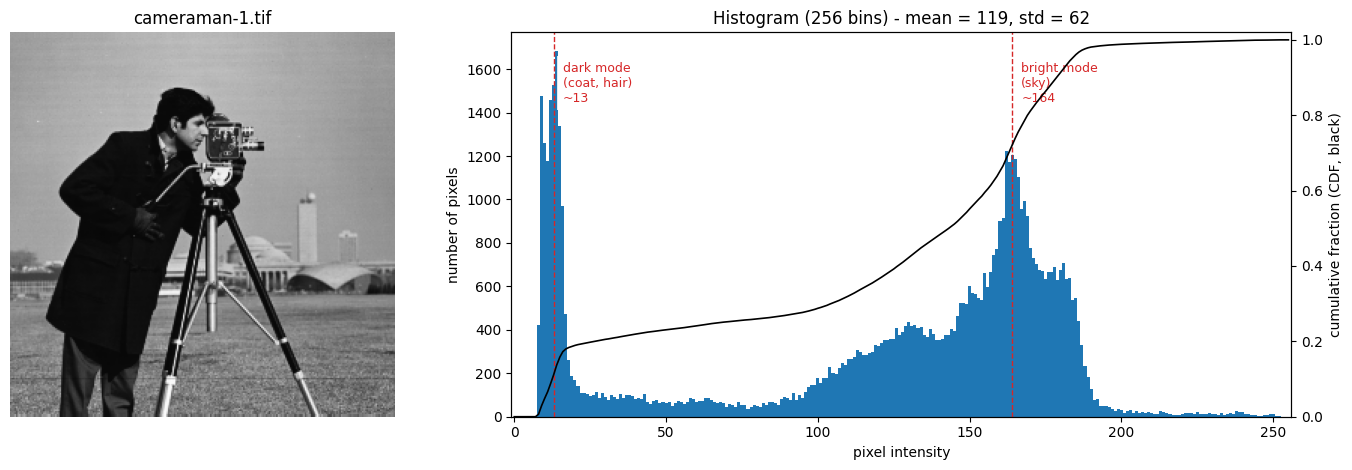

In [7]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("./cameraman-1.tif", cv2.IMREAD_GRAYSCALE)
assert img is not None, "Could not read ./cameraman-1.tif"
print("cameraman-1.tif:", img.shape, img.dtype)


def edge_stats(edges):
    """(number of edge pixels, number of 8-connected edge segments, number of tiny segments with < 10 px)."""
    e = (edges > 0).astype(np.uint8)
    n_labels, _, cc_stats, _ = cv2.connectedComponentsWithStats(e, connectivity=8)
    areas = cc_stats[1:, cv2.CC_STAT_AREA]  # label 0 is the background
    return int(e.sum()), int(n_labels - 1), int((areas < 10).sum())


def overlay(a, b):
    """RGB comparison of two binary edge maps: white = in both, red = only in a, green = only in b."""
    a, b = a > 0, b > 0
    rgb = np.zeros(a.shape + (3,), np.uint8)
    rgb[a & b] = (255, 255, 255)
    rgb[a & ~b] = (255, 0, 0)
    rgb[~a & b] = (0, 255, 0)
    return rgb


# ===== 1) Histogram of the pixel intensities of cameraman-1.tif =====
hist = np.bincount(img.ravel(), minlength=256)  # hist[k] = number of pixels with intensity k
hist_cv = cv2.calcHist([img], [0], None, [256], [0, 256]).ravel()
assert np.array_equal(hist, hist_cv.astype(np.int64)) and hist.sum() == img.size  # sanity check vs OpenCV

cdf = np.cumsum(hist) / img.size

# the two modes, located on a lightly smoothed histogram (5-bin moving average)
hist_smooth = np.convolve(hist, np.ones(5) / 5, mode="same")
dark_peak = int(np.argmax(hist_smooth[:100]))
bright_peak = 100 + int(np.argmax(hist_smooth[100:]))

print(f"#pixels = {img.size}, min = {img.min()}, max = {img.max()}, mean = {img.mean():.1f}, "
      f"median = {np.median(img):.0f}, std = {img.std():.1f}")
print(f"distinct grey levels used = {np.count_nonzero(hist)} / 256")
print(f"dark mode at ~{dark_peak}, bright mode at ~{bright_peak}")
print(f"pixels < 64: {100 * (img < 64).mean():.1f} %,  pixels >= 128: {100 * (img >= 128).mean():.1f} %")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1, 1.7]})
ax[0].imshow(img, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("cameraman-1.tif")
ax[0].axis("off")

ax[1].bar(np.arange(256), hist, width=1.0, color="tab:blue")
ax[1].set_xlim(-1, 256)
ax[1].set_xlabel("pixel intensity")
ax[1].set_ylabel("number of pixels")
ax[1].set_title(f"Histogram (256 bins) - mean = {img.mean():.0f}, std = {img.std():.0f}")
for p, name in ((dark_peak, "dark mode\n(coat, hair)"), (bright_peak, "bright mode\n(sky)")):
    ax[1].axvline(p, color="tab:red", ls="--", lw=1)
    ax[1].text(p + 3, hist.max() * 0.97, f"{name}\n~{p}", color="tab:red", fontsize=9, va="top",
               bbox=dict(fc="white", ec="none", alpha=0.85))
ax_cdf = ax[1].twinx()
ax_cdf.plot(np.arange(256), cdf, color="black", lw=1.2)
ax_cdf.set_ylabel("cumulative fraction (CDF, black)")
ax_cdf.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

**Observations:** The histogram has two clear peaks: a narrow one around 13 that comes from the dark coat and hair, and a wider one around 164 that comes mostly from the sky. The image already covers almost the whole range (min 7, max 253, and 247 of the 256 grey levels are used), so it is not under- or over-exposed. The CDF (black line) jumps at the two peaks and increases slowly between them.

## 2. Gamma correction
Implement gamma correction and compare the histogram of the corrected image with that of the original.

r = 64, gamma = 0.5 -> 128 (expected 255*sqrt(64/255) = 127.75 -> 128)
r = 64, gamma = 2.0 -> 16 (expected 255*(64/255)^2 = 16.06 -> 16)
gamma |  mean   std  min  max levels |  dark mode bright mode | std of dark px std of bright px
  0.4 | 176.6  54.2   61  254    165 |  13 -> 78    164 -> 214  |           20.5              9.4
  0.6 | 152.6  61.4   29  254    201 |  13 -> 43    164 -> 196  |           19.3             12.9
  1.0 | 118.7  62.3    7  253    247 |  13 -> 13    164 -> 164  |           13.1             18.1
  1.5 |  90.5  55.7    1  252    215 |  13 -> 3     164 -> 132  |            6.8             21.9
  2.5 |  55.6  41.5    0  250    171 |  13 -> 0     164 -> 85   |            1.6             24.4


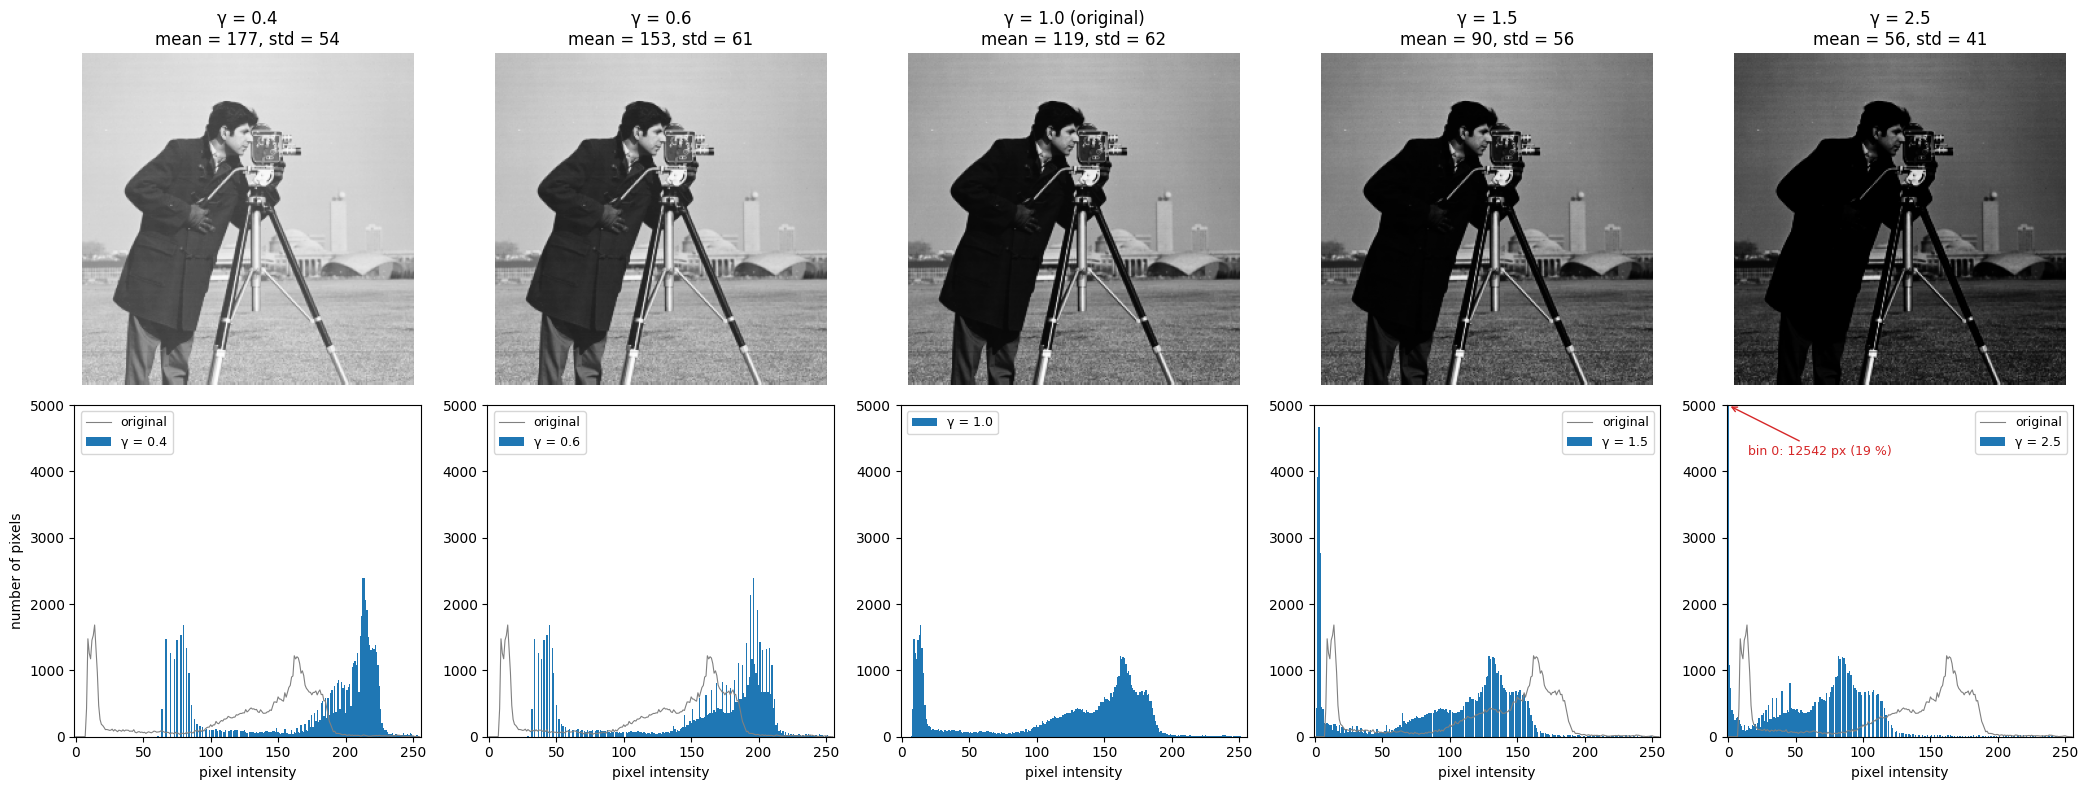

gamma = 0.4: slope > 1 (tones stretched) for r < 55.4, slope < 1 (tones compressed) for r > 55.4
gamma = 0.6: slope > 1 (tones stretched) for r < 71.1, slope < 1 (tones compressed) for r > 71.1
gamma = 1.5: slope > 1 (tones stretched) for r > 113.3, slope < 1 (tones compressed) for r < 113.3
gamma = 2.5: slope > 1 (tones stretched) for r > 138.4, slope < 1 (tones compressed) for r < 138.4


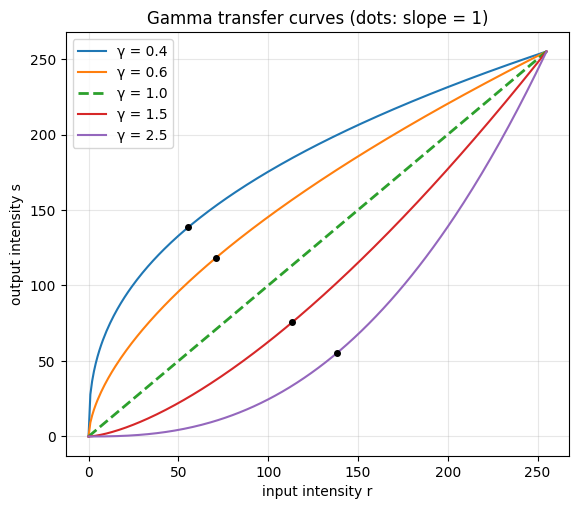

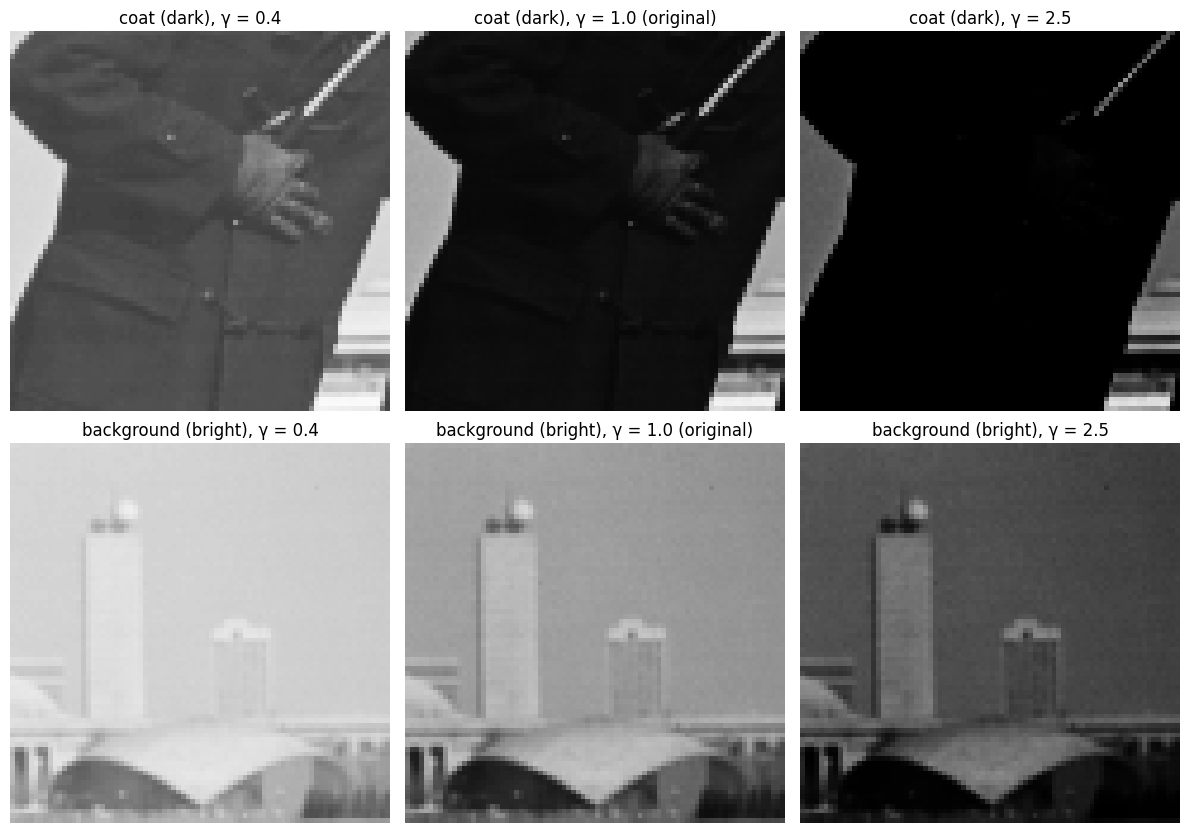

In [8]:
def gamma_correct(img, gamma=1.0):
    """
    Gamma (power-law) correction:  s = L * (r / L) ** gamma,  with L the maximum value of the dtype (255 for uint8).
      gamma < 1 -> brightens, stretches the dark tones and compresses the bright tones
      gamma > 1 -> darkens, compresses the dark tones and stretches the bright tones
      gamma = 1 -> identity
    For 8-bit images a 256-entry look-up table is used; values are rounded (not truncated) and clipped.
    """
    if gamma <= 0:
        raise ValueError("gamma must be > 0")
    img = np.asarray(img)
    if img.dtype == np.uint8:
        lut = np.clip(np.round(255.0 * (np.arange(256) / 255.0) ** gamma), 0, 255).astype(np.uint8)
        return cv2.LUT(img, lut)
    if np.issubdtype(img.dtype, np.integer):
        L = np.iinfo(img.dtype).max
        out = np.round(L * (img.astype(np.float64) / L) ** gamma)
        return np.clip(out, 0, L).astype(img.dtype)
    return np.clip(img, 0.0, 1.0) ** gamma  # floating-point image assumed to be in [0, 1]


# sanity checks
levels = np.arange(256, dtype=np.uint8).reshape(1, -1)
assert np.array_equal(gamma_correct(img, 1.0), img)                       # gamma = 1 is the identity
assert np.all(np.diff(gamma_correct(levels, 0.4).astype(int)) >= 0)     # the mapping is monotonic
print("r = 64, gamma = 0.5 ->", gamma_correct(levels, 0.5)[0, 64], "(expected 255*sqrt(64/255) = 127.75 -> 128)")
print("r = 64, gamma = 2.0 ->", gamma_correct(levels, 2.0)[0, 64], "(expected 255*(64/255)^2 = 16.06 -> 16)")


# ===== Experiments: several gamma values =====
gammas = [0.4, 0.6, 1.0, 1.5, 2.5]
corrected = {g: gamma_correct(img, g) for g in gammas}
dark_px, bright_px = img < 64, img >= 128  # pixel groups defined on the ORIGINAL image

print(f"{'gamma':>5} | {'mean':>5} {'std':>5} {'min':>4} {'max':>4} {'levels':>6} | {'dark mode':>10} {'bright mode':>11} |"
      f" {'std of dark px':>14} {'std of bright px':>16}")
for g in gammas:
    out = corrected[g]
    lut = gamma_correct(levels, g).ravel()
    print(f"{g:>5} | {out.mean():5.1f} {out.std():5.1f} {out.min():4d} {out.max():4d} {len(np.unique(out)):6d} |"
          f" {dark_peak:>3} -> {lut[dark_peak]:<4d} {bright_peak:>4} -> {lut[bright_peak]:<4d} |"
          f" {out[dark_px].std():14.1f} {out[bright_px].std():16.1f}")

# images (top) and their histograms (bottom); the grey line is the histogram of the original image
hists = {g: np.bincount(corrected[g].ravel(), minlength=256) for g in gammas}
y_max = 5000  # common y-axis; taller bins are clipped and their count is written on the plot
fig, ax = plt.subplots(2, len(gammas), figsize=(21, 8))
for i, g in enumerate(gammas):
    out = corrected[g]
    ax[0, i].imshow(out, cmap="gray", vmin=0, vmax=255)
    ax[0, i].set_title(f"γ = {g}" + (" (original)" if g == 1 else "") + f"\nmean = {out.mean():.0f}, std = {out.std():.0f}")
    ax[0, i].axis("off")
    ax[1, i].bar(np.arange(256), hists[g], width=1.0, color="tab:blue", label=f"γ = {g}")
    if g != 1:
        ax[1, i].plot(np.arange(256), hist, color="gray", lw=0.8, label="original")
    for k in np.flatnonzero(hists[g] > y_max):
        ax[1, i].annotate(f"bin {k}: {hists[g][k]} px ({100 * hists[g][k] / img.size:.0f} %)", xy=(k, y_max),
                          xytext=(k + 15, 0.85 * y_max), fontsize=9, color="tab:red",
                          arrowprops=dict(arrowstyle="->", color="tab:red"))
    ax[1, i].set_xlim(-1, 256)
    ax[1, i].set_ylim(0, y_max)
    ax[1, i].set_xlabel("pixel intensity")
    ax[1, i].legend(fontsize=9, loc="upper right" if g > 1 else "upper left")
ax[1, 0].set_ylabel("number of pixels")
plt.tight_layout()
plt.show()


# transfer curves s = 255 * (r/255)^gamma; the dots mark where the slope ds/dr equals 1
r = np.arange(256) / 255.0
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for g in gammas:
    ax.plot(255 * r, 255 * r ** g, label=f"γ = {g}", lw=2 if g == 1 else 1.5, ls="--" if g == 1 else "-")
    if g != 1:
        r1 = g ** (1 / (1 - g))  # solution of gamma * r^(gamma - 1) = 1
        ax.plot(255 * r1, 255 * r1 ** g, "ko", ms=4)
        print(f"gamma = {g}: slope > 1 (tones stretched) for r {'<' if g < 1 else '>'} {255 * r1:.1f}, "
              f"slope < 1 (tones compressed) for r {'>' if g < 1 else '<'} {255 * r1:.1f}")
ax.set_xlabel("input intensity r")
ax.set_ylabel("output intensity s")
ax.set_title("Gamma transfer curves (dots: slope = 1)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# zoomed crops: a dark region (coat) and a bright region (background buildings / sky)
crops = {"coat (dark)": (slice(95, 175), slice(35, 115)), "background (bright)": (slice(95, 175), slice(176, 256))}
fig, ax = plt.subplots(2, 3, figsize=(12, 8.5))
for row, (name, (ys, xs)) in enumerate(crops.items()):
    for col, g in enumerate([0.4, 1.0, 2.5]):
        ax[row, col].imshow(corrected[g][ys, xs], cmap="gray", vmin=0, vmax=255, interpolation="nearest")
        ax[row, col].set_title(f"{name}, γ = {g}" + (" (original)" if g == 1 else ""))
        ax[row, col].axis("off")
plt.tight_layout()
plt.show()

**Your analysis:**

I implemented gamma correction as s = 255 · (r/255)^γ using a lookup table (with rounding), and tested γ = 0.4, 0.6, 1.0, 1.5 and 2.5 on the cameraman image. Like in the demo, γ < 1 makes the image brighter and γ > 1 makes it darker.

With γ < 1 the whole histogram moves to the right. For γ = 0.4 the dark peak (the coat) moves from about 13 to about 78 and becomes wider, so details in the coat like the folds and the hand become visible. But the bright part gets squeezed (the bright peak goes from 164 to 214), so the sky and the buildings look washed out. With γ > 1 it is the opposite: the histogram moves to the left, and for γ = 2.5 all the dark pixels (below 64) end up between 0 and 8, with about 19% of the image exactly 0, so the coat turns completely black. On the other hand, the bright range is stretched and the buildings stand out a bit more against the sky.

This happens because of the slope of the gamma curve. Where the curve is steep, the grey levels are spread apart (more contrast), and where it is flat they are pushed together (less contrast). For γ = 0.4 the curve is steep for dark values (below ~55) and flat for bright values, and for γ = 2.5 it is the other way around (steep above ~138).

I also noticed that the new histograms have gaps and spikes, like a comb. This is because the image is 8-bit: in the stretched part some output values are never used, and in the compressed part several input values merge into one. The number of grey levels drops from 247 to 165 (γ = 0.4) and 171 (γ = 2.5), so some information is lost.

Finally, the cameraman image already uses almost the full range (7 to 253), so gamma does not really increase the overall contrast. The standard deviation actually decreases for all γ ≠ 1 (62.3 → 54.2 for γ = 0.4 and 41.5 for γ = 2.5). Gamma just moves the contrast to the dark or to the bright part, depending on what we want to see. For this image, γ ≈ 0.6 looks like a good compromise because the coat becomes visible without losing too much in the background.

## 3. Effect of the Canny parameters
Using `cv2.Canny`, study the effect of the lower/upper thresholds, the Sobel aperture size and the
L1/L2 gradient magnitude. Then analyse your results.

both thresholds increased
   (low, high) = ( 25,  75): edge px =  9878, segments =  373, tiny segments (<10 px) =  243
   (low, high) = ( 50, 150): edge px =  8182, segments =  210, tiny segments (<10 px) =  102
   (low, high) = (100, 200): edge px =  6105, segments =  202, tiny segments (<10 px) =   93
   (low, high) = (200, 400): edge px =  3212, segments =   52, tiny segments (<10 px) =   21
upper fixed at 200, lower varied
   (low, high) = ( 20, 200): edge px =  8124, segments =  139, tiny segments (<10 px) =   56
   (low, high) = (100, 200): edge px =  6105, segments =  202, tiny segments (<10 px) =   93
   (low, high) = (150, 200): edge px =  4881, segments =  302, tiny segments (<10 px) =  240
   (low, high) = (200, 200): edge px =  4054, segments =  419, tiny segments (<10 px) =  385
lower fixed at 100, upper varied
   (low, high) = (100, 100): edge px =  7520, segments =  648, tiny segments (<10 px) =  517
   (low, high) = (100, 200): edge px =  6105, segments =  202, tiny seg

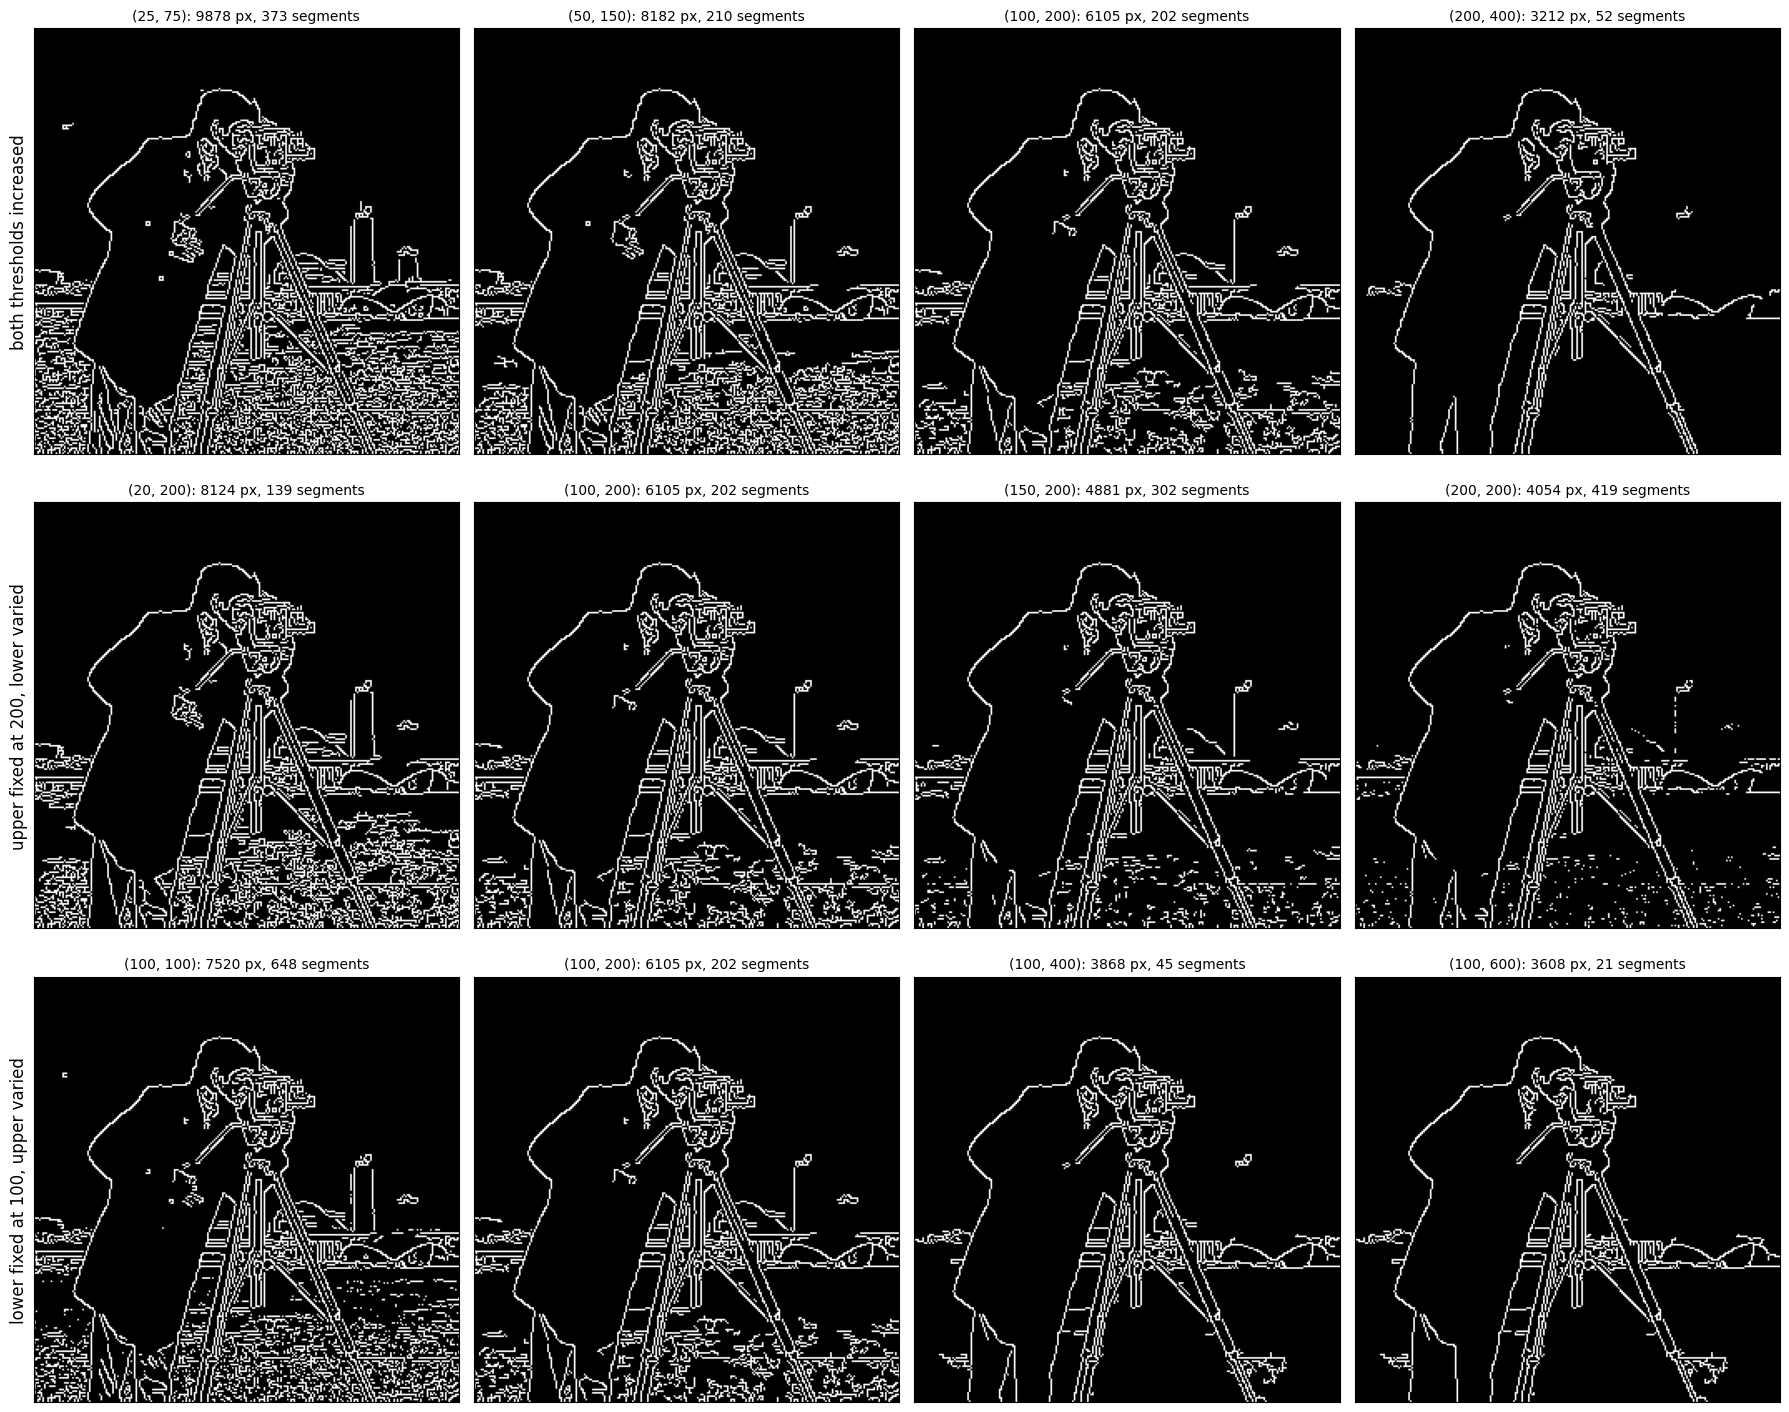

apertureSize = 3: response to a unit step = 4  ->  x1 compared to 3x3
apertureSize = 5: response to a unit step = 48  ->  x12 compared to 3x3
apertureSize = 7: response to a unit step = 640  ->  x160 compared to 3x3
same thresholds
   apertureSize = 3, (low, high) = (100, 200): edge px =  6105, segments =  202, tiny segments =   93
   apertureSize = 5, (low, high) = (100, 200): edge px = 17631, segments =  671, tiny segments =  389
   apertureSize = 7, (low, high) = (100, 200): edge px = 19529, segments =  972, tiny segments =  673
thresholds scaled by the kernel gain
   apertureSize = 3, (low, high) = (100, 200): edge px =  6105, segments =  202, tiny segments =   93
   apertureSize = 5, (low, high) = (1200, 2400): edge px =  4335, segments =  109, tiny segments =   43
   apertureSize = 7, (low, high) = (16000, 32000): edge px =  3929, segments =   83, tiny segments =   27


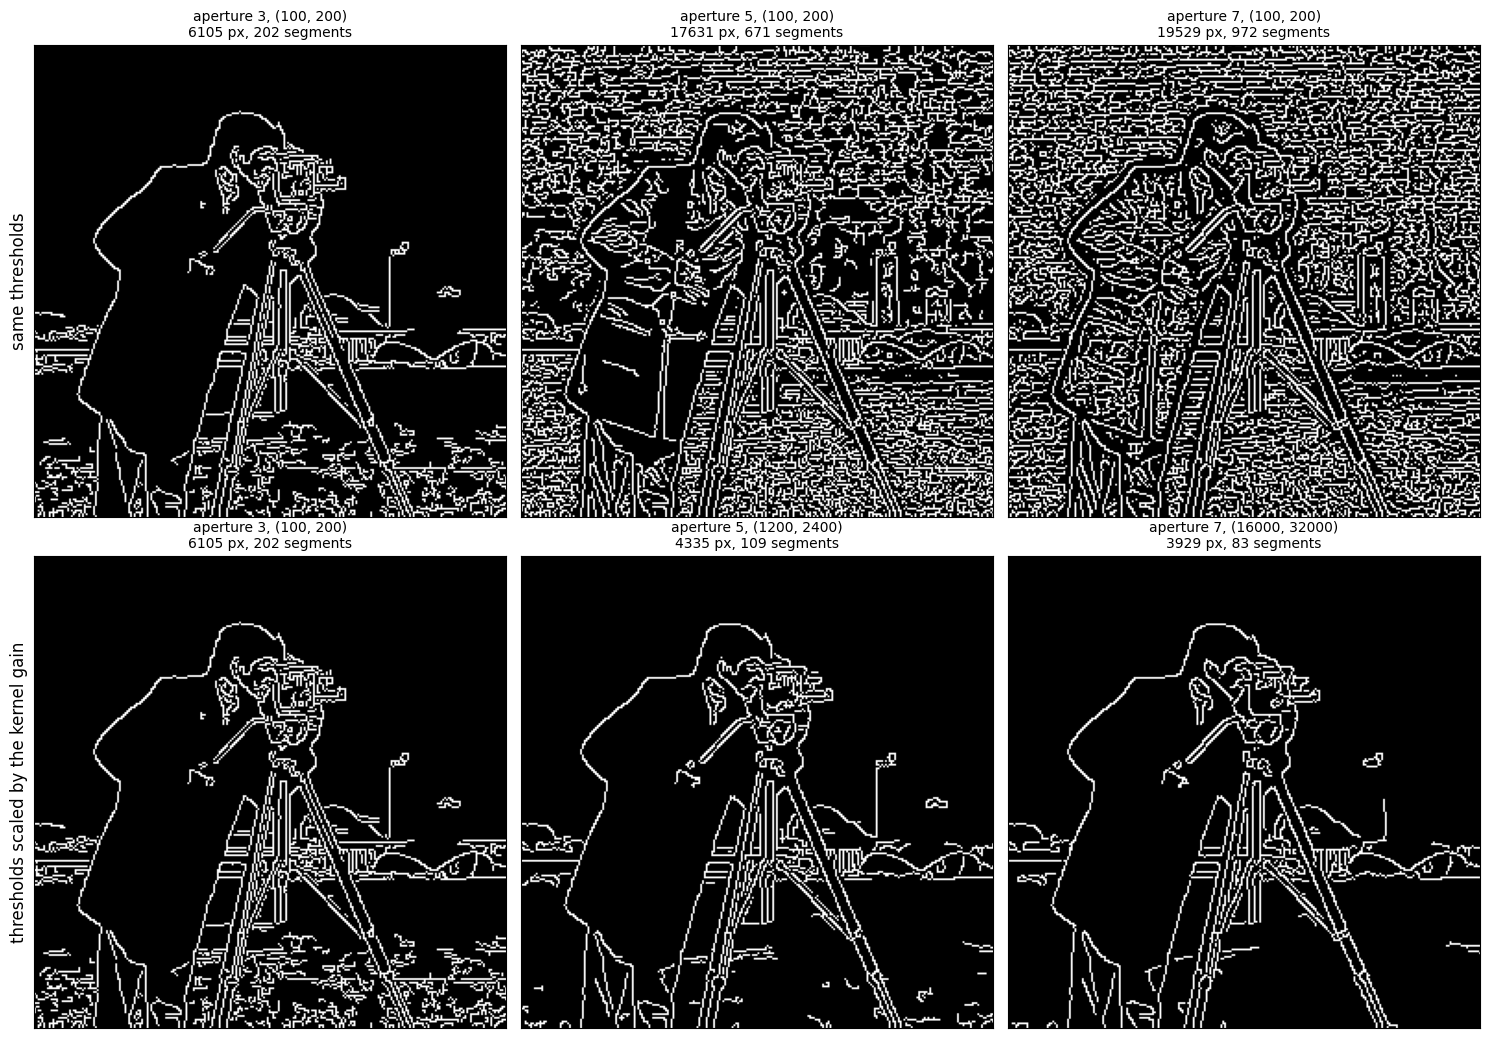

L1: edge px = 6105, segments = 202, tiny segments = 93
L2: edge px = 4786, segments = 126, tiny segments = 49
pixels in both = 4558, only L1 = 1547, only L2 = 228
L1/L2 magnitude ratio (pixels with |G| > 50): min = 1.000, max = 1.414 (sqrt(2) = 1.414), mean = 1.240
diagonal gradient direction: 52.7 % of the L1-only pixels vs 36.0 % of the common edge pixels
median L2 magnitude: L1-only pixels = 121, common pixels = 378
L1-only pixels located in the ground region (rows >= 170): 82.6 %


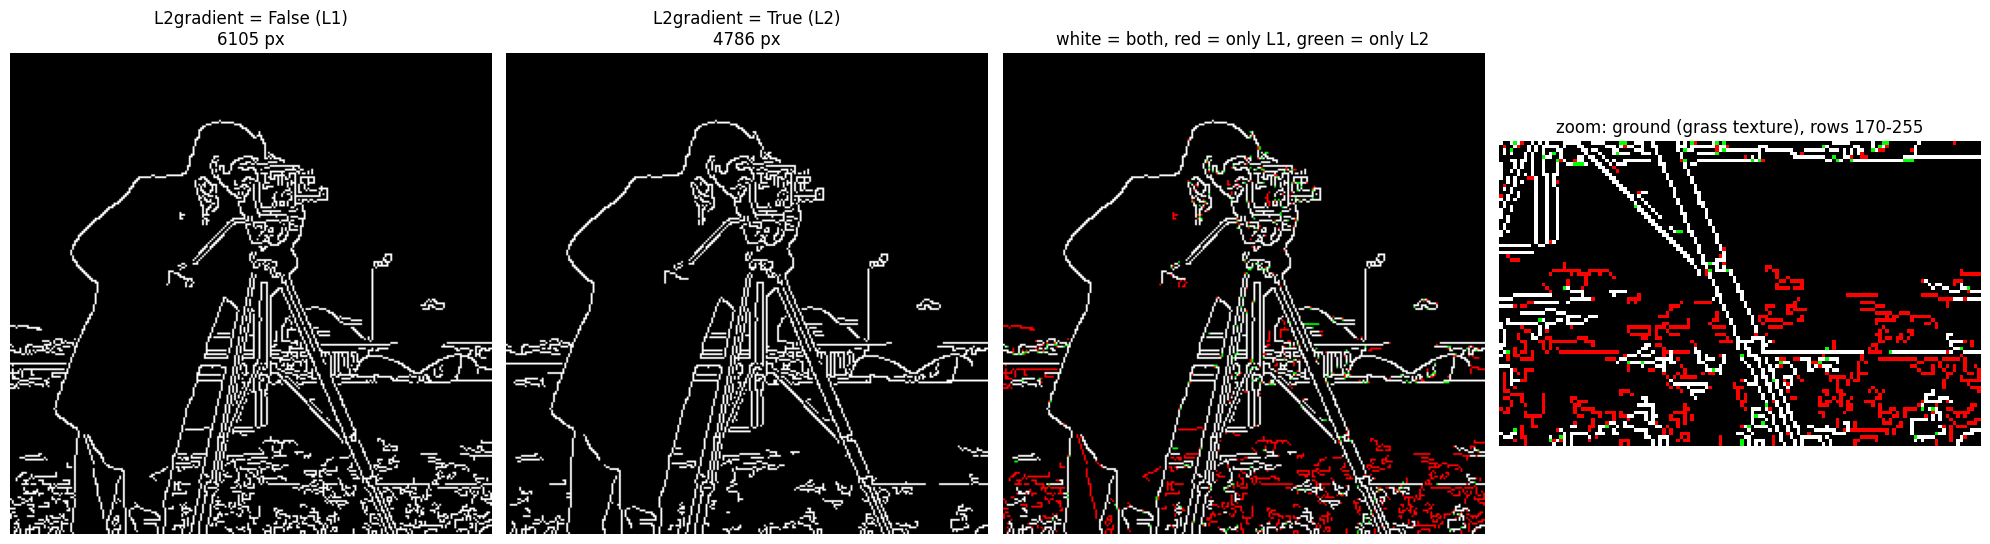

In [9]:
# 3a) Lower / upper thresholds  (other parameters at the OpenCV defaults: apertureSize = 3, L2gradient = False)
threshold_sets = {
    "both thresholds increased": [(25, 75), (50, 150), (100, 200), (200, 400)],
    "upper fixed at 200, lower varied": [(20, 200), (100, 200), (150, 200), (200, 200)],
    "lower fixed at 100, upper varied": [(100, 100), (100, 200), (100, 400), (100, 600)],
}
fig, ax = plt.subplots(3, 4, figsize=(18, 14.5))
for row, (name, pairs) in enumerate(threshold_sets.items()):
    print(name)
    for col, (lo, hi) in enumerate(pairs):
        e = cv2.Canny(img, lo, hi)
        n, segs, tiny = edge_stats(e)
        print(f"   (low, high) = ({lo:>3}, {hi:>3}): edge px = {n:5d}, segments = {segs:4d}, tiny segments (<10 px) = {tiny:4d}")
        ax[row, col].imshow(e, cmap="gray")
        ax[row, col].set_title(f"({lo}, {hi}): {n} px, {segs} segments", fontsize=10)
        ax[row, col].set_xticks([]); ax[row, col].set_yticks([])
    ax[row, 0].set_ylabel(name, fontsize=12)
plt.tight_layout()
plt.show()


# 3b) Sobel aperture size (3, 5, 7).  The gradient magnitude grows strongly with the kernel size,
#     so first measure the response of each kernel to an ideal unit step edge.
step = np.zeros((32, 32)); step[:, 16:] = 1.0
gain = {}
for k in (3, 5, 7):
    peak = np.abs(cv2.Sobel(step, cv2.CV_64F, 1, 0, ksize=k)).max()
    gain[k] = peak / 4.0
    print(f"apertureSize = {k}: response to a unit step = {peak:.0f}  ->  x{gain[k]:.0f} compared to 3x3")

lo, hi = 100, 200
configs = [("same thresholds", {k: (lo, hi) for k in (3, 5, 7)}),
           ("thresholds scaled by the kernel gain", {k: (lo * gain[k], hi * gain[k]) for k in (3, 5, 7)})]
fig, ax = plt.subplots(2, 3, figsize=(15, 10.5))
for row, (name, thr) in enumerate(configs):
    print(name)
    for col, k in enumerate((3, 5, 7)):
        e = cv2.Canny(img, thr[k][0], thr[k][1], apertureSize=k)
        n, segs, tiny = edge_stats(e)
        print(f"   apertureSize = {k}, (low, high) = ({thr[k][0]:.0f}, {thr[k][1]:.0f}): "
              f"edge px = {n:5d}, segments = {segs:4d}, tiny segments = {tiny:4d}")
        ax[row, col].imshow(e, cmap="gray")
        ax[row, col].set_title(f"aperture {k}, ({thr[k][0]:.0f}, {thr[k][1]:.0f})\n{n} px, {segs} segments", fontsize=10)
        ax[row, col].set_xticks([]); ax[row, col].set_yticks([])
    ax[row, 0].set_ylabel(name, fontsize=12)
plt.tight_layout()
plt.show()


# 3c) L1 (|Gx| + |Gy|, default) vs L2 (sqrt(Gx^2 + Gy^2)) gradient magnitude, same thresholds (100, 200)
lo, hi = 100, 200
e_l1 = cv2.Canny(img, lo, hi, L2gradient=False)
e_l2 = cv2.Canny(img, lo, hi, L2gradient=True)

gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
mag_l1, mag_l2 = np.abs(gx) + np.abs(gy), np.hypot(gx, gy)
ratio = mag_l1[mag_l2 > 50] / mag_l2[mag_l2 > 50]
angle = np.degrees(np.arctan2(gy, gx)) % 180
diagonal = (np.abs(angle - 45) <= 22.5) | (np.abs(angle - 135) <= 22.5)   # gradient within 22.5 deg of a diagonal

only_l1, only_l2, both = (e_l1 > 0) & (e_l2 == 0), (e_l2 > 0) & (e_l1 == 0), (e_l1 > 0) & (e_l2 > 0)
for name, e in (("L1", e_l1), ("L2", e_l2)):
    n, segs, tiny = edge_stats(e)
    print(f"{name}: edge px = {n}, segments = {segs}, tiny segments = {tiny}")
print(f"pixels in both = {both.sum()}, only L1 = {only_l1.sum()}, only L2 = {only_l2.sum()}")
print(f"L1/L2 magnitude ratio (pixels with |G| > 50): min = {ratio.min():.3f}, max = {ratio.max():.3f} (sqrt(2) = 1.414), mean = {ratio.mean():.3f}")
print(f"diagonal gradient direction: {100 * diagonal[only_l1].mean():.1f} % of the L1-only pixels vs "
      f"{100 * diagonal[both].mean():.1f} % of the common edge pixels")
print(f"median L2 magnitude: L1-only pixels = {np.median(mag_l2[only_l1]):.0f}, common pixels = {np.median(mag_l2[both]):.0f}")
print(f"L1-only pixels located in the ground region (rows >= 170): {100 * only_l1[170:].sum() / only_l1.sum():.1f} %")

fig, ax = plt.subplots(1, 4, figsize=(20, 5.5))
ax[0].imshow(e_l1, cmap="gray"); ax[0].set_title(f"L2gradient = False (L1)\n{int((e_l1 > 0).sum())} px")
ax[1].imshow(e_l2, cmap="gray"); ax[1].set_title(f"L2gradient = True (L2)\n{int((e_l2 > 0).sum())} px")
ax[2].imshow(overlay(e_l1, e_l2)); ax[2].set_title("white = both, red = only L1, green = only L2")
ys, xs = slice(170, 256), slice(120, 256)
ax[3].imshow(overlay(e_l1, e_l2)[ys, xs], interpolation="nearest"); ax[3].set_title("zoom: ground (grass texture), rows 170-255")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()


**Your analysis:**

I changed one parameter at a time and kept the others at the OpenCV defaults (aperture 3, L1). To compare the results I also counted the edge pixels and the number of connected edge segments.

**Thresholds.** Canny uses two thresholds: pixels above the upper threshold are strong edges, and pixels between the two are only kept if they are connected to a strong edge (hysteresis).

- When I increased the upper threshold (with lower = 100), the number of edge pixels dropped a lot (7520 → 3608 from 100 to 600). The weak edges like the grass and the buildings disappear first, and only the strong outline of the man and the tripod stays.
- When I decreased the lower threshold (with upper = 200), I got more edge pixels (4054 → 8124) but fewer segments (419 → 139), which means the edges become longer and more connected. When lower = upper there is no hysteresis, so the edges break into many small pieces. With a very low value (20) the edges start to spread into the grass texture.
- Increasing both together goes from a very cluttered result at (25, 75) to only the main silhouette at (200, 400). I think (100, 200) is a good balance for this image, and it also matches the 1:2 to 1:3 ratio recommended by Canny.

**Aperture size.** With the same thresholds, apertures 5 and 7 give far more edges (17,631 and 19,529 pixels vs 6105), mostly texture. This is because bigger Sobel kernels give much bigger gradient values: I measured the response to a step edge as 4, 48 and 640 for sizes 3, 5 and 7. So I scaled the thresholds by 12 and 160. After that, the bigger apertures give smoother and cleaner edges (4335 and 3929 pixels) because they smooth over a bigger area, but they lose small details like the parts of the camera.

**L1 vs L2.** L2 is the real magnitude sqrt(Gx² + Gy²), while L1 = |Gx| + |Gy| is an approximation that is always greater or equal (up to √2 times for diagonal edges; the mean ratio here was 1.24). Because of that, L1 lets more pixels pass the same thresholds: 6105 vs 4786 edge pixels. Most of the extra L1 edges are weak edges in the grass (82.6%), and they are more often diagonal. So L2 is more accurate, and L1 is just cheaper to compute.

## 4. Sobel edge detection
Implement Sobel edge detection and apply it to the same image.

max |Gx - cv2.Sobel| = 0.0   max |Gy - cv2.Sobel| = 0.0
|G|: max = 914.6 (theoretical max 4*255*sqrt(2) = 1442.5), median = 15.6, 90th percentile = 192.2


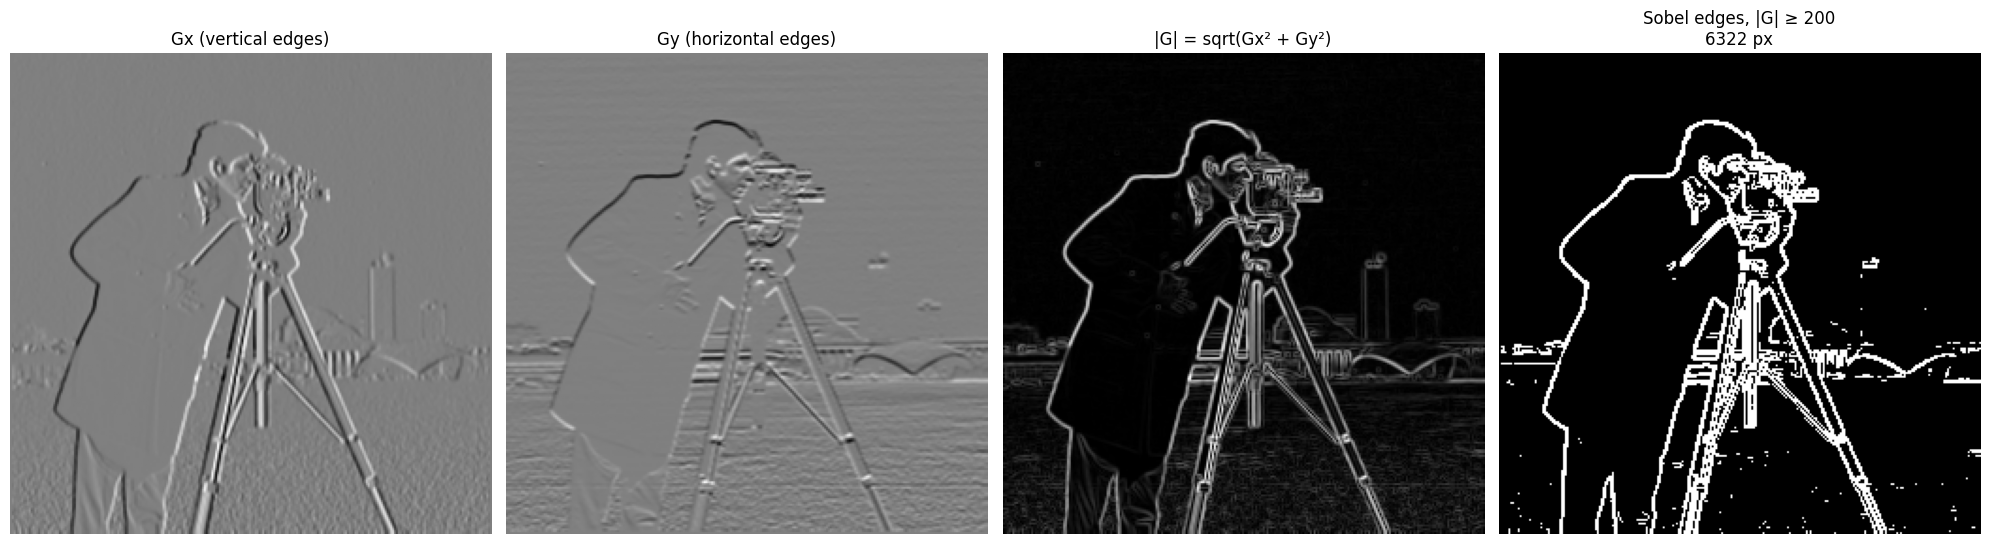

threshold = 100: edge px = 12126, segments =  317, tiny segments (<10 px) =  258
threshold = 200: edge px =  6322, segments =  128, tiny segments (<10 px) =  110
threshold = 300: edge px =  4398, segments =   63, tiny segments (<10 px) =   47
threshold = 400: edge px =  3054, segments =   94, tiny segments (<10 px) =   57


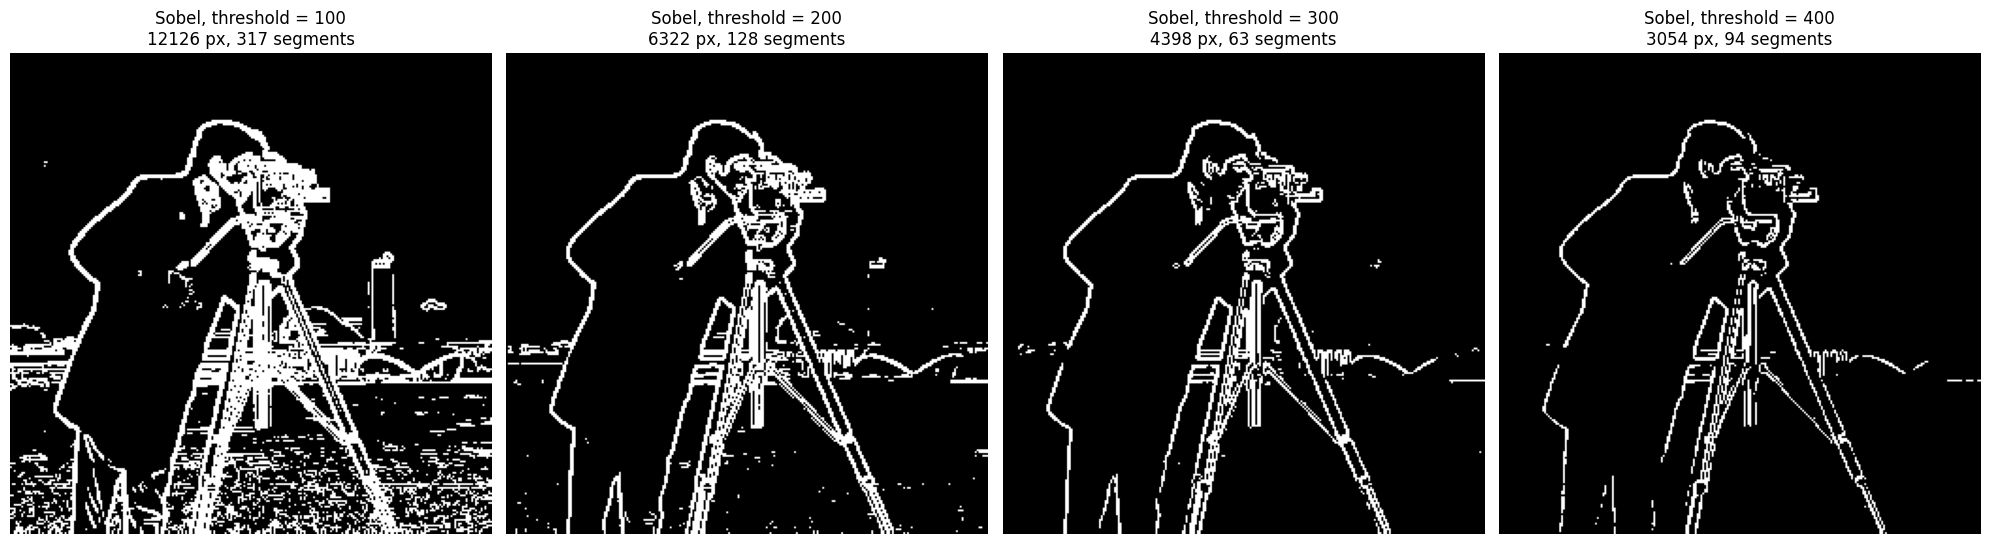

In [10]:
SOBEL_X = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float64)   # responds to horizontal intensity changes (vertical edges)
SOBEL_Y = SOBEL_X.T                                  # responds to vertical intensity changes (horizontal edges)


def sobel_edge(img, threshold=200, return_all=False):
    """
    Sobel edge detection implemented from scratch with NumPy:
      1. Gx, Gy = correlation of the image with the 3x3 Sobel kernels (reflect-101 border, as OpenCV's default)
      2. gradient magnitude |G| = sqrt(Gx^2 + Gy^2)
      3. edge map = |G| >= threshold  (uint8, values 0 / 255)
    If return_all is True, returns (edges, magnitude, Gx, Gy).
    """
    f = np.asarray(img, dtype=np.float64)
    if f.ndim != 2:
        raise ValueError("sobel_edge expects a single-channel (grayscale) image")
    H, W = f.shape
    padded = np.pad(f, 1, mode="reflect")  # numpy 'reflect' == cv2.BORDER_REFLECT_101
    gx = np.zeros_like(f)
    gy = np.zeros_like(f)
    for i in range(3):
        for j in range(3):
            window = padded[i:i + H, j:j + W]  # neighbour at offset (i - 1, j - 1) of every pixel
            gx += SOBEL_X[i, j] * window
            gy += SOBEL_Y[i, j] * window
    magnitude = np.sqrt(gx ** 2 + gy ** 2)
    edges = np.where(magnitude >= threshold, 255, 0).astype(np.uint8)
    if return_all:
        return edges, magnitude, gx, gy
    return edges


edges_sobel, mag, gx_s, gy_s = sobel_edge(img, threshold=200, return_all=True)

# verification against OpenCV's implementation
gx_cv = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
gy_cv = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
print("max |Gx - cv2.Sobel| =", np.abs(gx_s - gx_cv).max(), "  max |Gy - cv2.Sobel| =", np.abs(gy_s - gy_cv).max())
print(f"|G|: max = {mag.max():.1f} (theoretical max 4*255*sqrt(2) = {4 * 255 * np.sqrt(2):.1f}), "
      f"median = {np.median(mag):.1f}, 90th percentile = {np.percentile(mag, 90):.1f}")

fig, ax = plt.subplots(1, 4, figsize=(20, 5.5))
v = np.abs(gx_s).max()
ax[0].imshow(gx_s, cmap="gray", vmin=-v, vmax=v); ax[0].set_title("Gx (vertical edges)")
ax[1].imshow(gy_s, cmap="gray", vmin=-v, vmax=v); ax[1].set_title("Gy (horizontal edges)")
ax[2].imshow(mag, cmap="gray"); ax[2].set_title("|G| = sqrt(Gx² + Gy²)")
ax[3].imshow(edges_sobel, cmap="gray"); ax[3].set_title(f"Sobel edges, |G| ≥ 200\n{int((edges_sobel > 0).sum())} px")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

# effect of the single threshold
fig, ax = plt.subplots(1, 4, figsize=(20, 5.5))
for a, T in zip(ax, (100, 200, 300, 400)):
    e = sobel_edge(img, threshold=T)
    n, segs, tiny = edge_stats(e)
    print(f"threshold = {T}: edge px = {n:5d}, segments = {segs:4d}, tiny segments (<10 px) = {tiny:4d}")
    a.imshow(e, cmap="gray"); a.set_title(f"Sobel, threshold = {T}\n{n} px, {segs} segments"); a.axis("off")
plt.tight_layout()
plt.show()

**Notes:** I implemented Sobel from scratch by applying the two 3×3 kernels with NumPy, then computing the magnitude sqrt(Gx² + Gy²) and thresholding it. To check my implementation, I compared Gx and Gy with cv2.Sobel and the difference is exactly 0. Gx shows the vertical edges (tripod legs, side of the coat) and Gy the horizontal ones (horizon, roofs). With a single threshold there is a trade-off: T = 100 keeps a lot of grass texture (12,126 edge pixels), while T = 400 removes it but the edges start to break (the number of segments goes up again from 63 at T = 300 to 94). So I used T = 200 as a compromise.

## 5. Canny vs Sobel
Compare the results of the Canny and Sobel edge detectors. What are the differences and why?

Sobel (|G| >= 200) : edge px =  6322, segments =  128, tiny segments (<10 px) =  110, mean edge width = 1.90 px
Canny (100, 200)   : edge px =  4786, segments =  126, tiny segments (<10 px) =   49, mean edge width = 1.02 px

Canny pixels that are also Sobel pixels: 3422 (71.5 % of Canny)
Canny pixels with |G| < 200 (weak pixels, kept only through hysteresis): 1364
Sobel pixels removed by Canny: 2900 (45.9 % of Sobel), of which 15 on the 1-px image border (cv2.Canny pads the image differently)


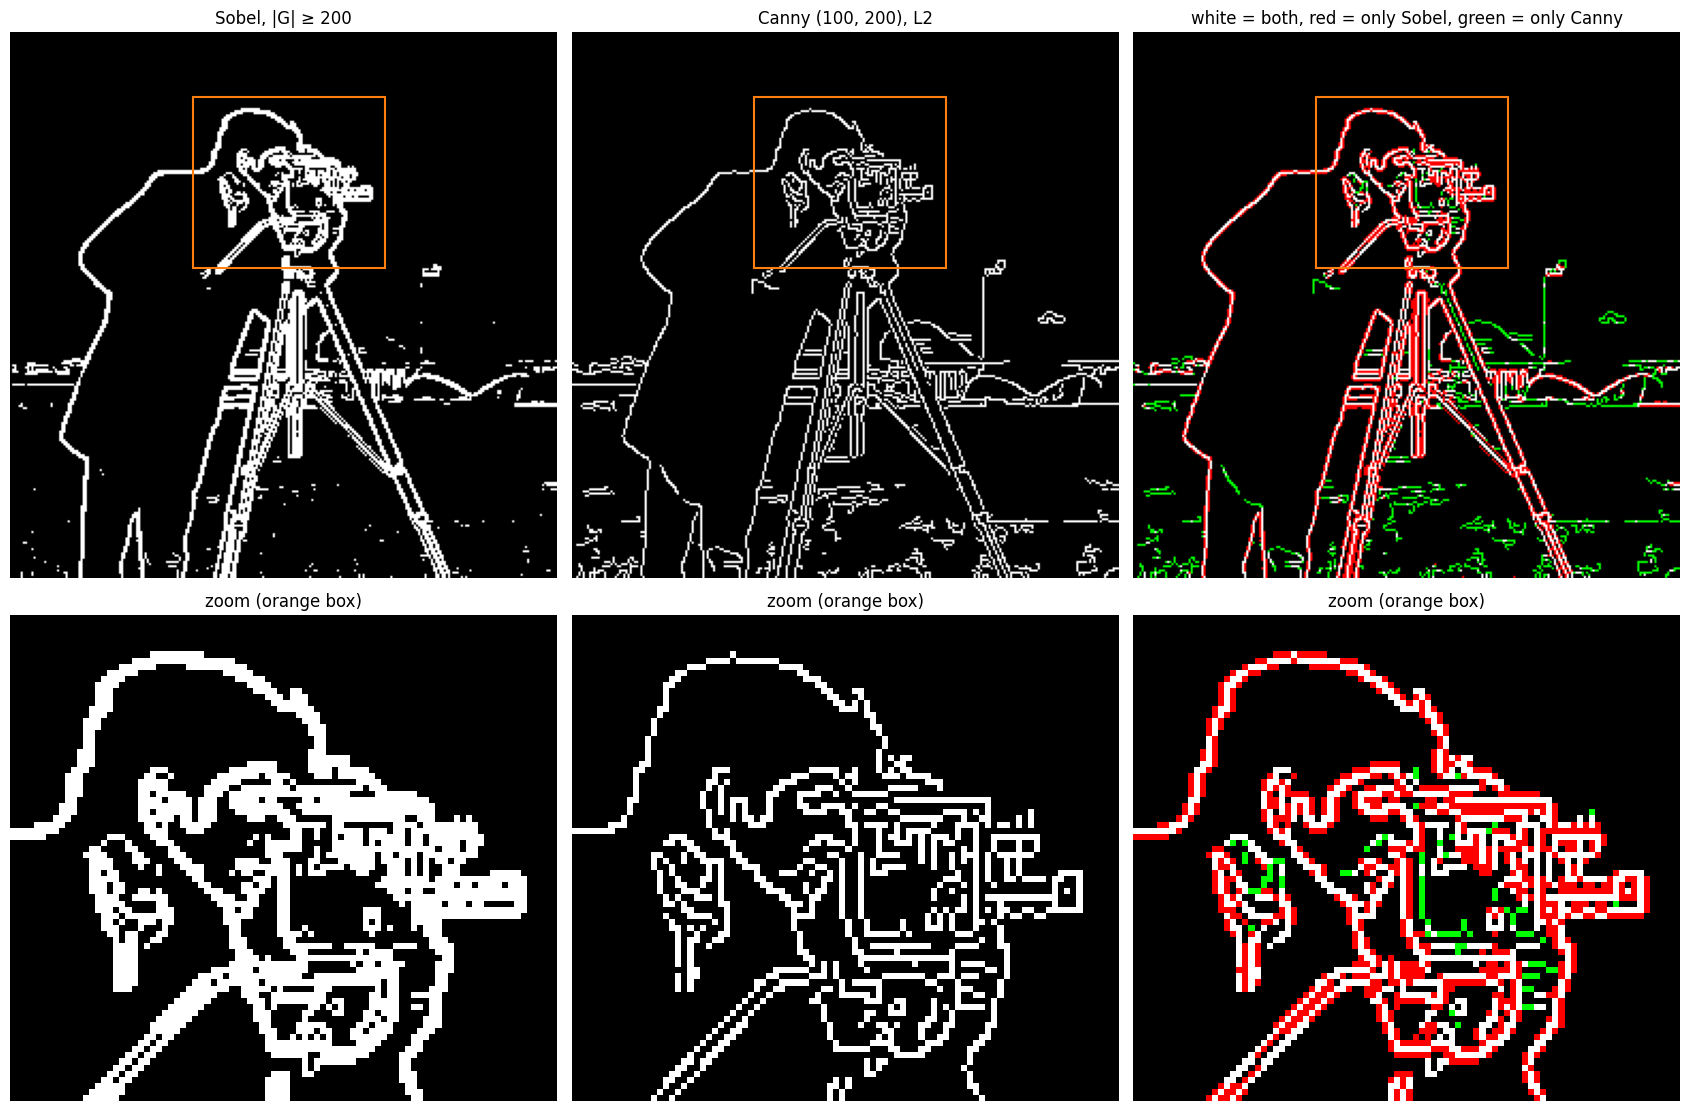

noisy                            Sobel: edge px =  8399, false edge px in the sky =  136
noisy                            Canny: edge px = 11257, false edge px in the sky =  924
noisy + Gaussian 5x5, sigma 1.4  Sobel: edge px =  3642, false edge px in the sky =    0
noisy + Gaussian 5x5, sigma 1.4  Canny: edge px =  2521, false edge px in the sky =    0


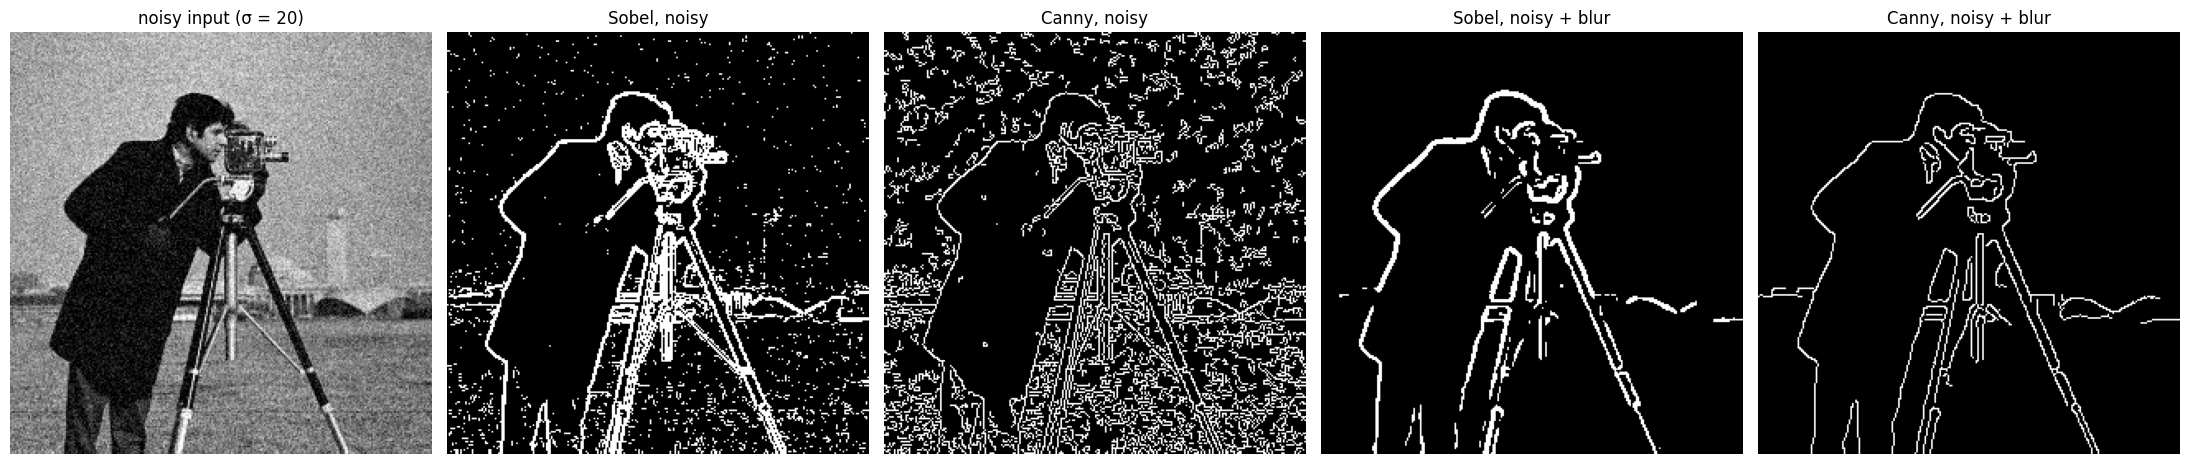

In [11]:
# 5) Canny vs Sobel on the same image with a like-for-like setting:
#    both use the 3x3 Sobel gradient and the L2 magnitude; the Sobel threshold (200) = Canny's upper threshold,
#    Canny's lower threshold = 100 (ratio 1:2).
T = 200
edges_canny = cv2.Canny(img, T // 2, T, apertureSize=3, L2gradient=True)
edges_sobel, mag, gx_s, gy_s = sobel_edge(img, threshold=T, return_all=True)


def mean_edge_width(edges, gx, gy):
    """Average edge thickness in pixels, measured ACROSS the edges: near-vertical edges (|Gx| > 2|Gy|) along the
    rows, near-horizontal edges (|Gy| > 2|Gx|) along the columns, as the length of runs of consecutive edge pixels."""
    e = edges > 0
    runs = []
    for m in (e & (np.abs(gx) > 2 * np.abs(gy)), (e & (np.abs(gy) > 2 * np.abs(gx))).T):
        d = np.diff(np.pad(m.astype(np.int8), ((0, 0), (1, 1))), axis=1)
        starts, ends = np.argwhere(d == 1), np.argwhere(d == -1)  # both sorted row by row, so they pair up
        runs.append(ends[:, 1] - starts[:, 1])
    return float(np.concatenate(runs).mean())


for name, e in (("Sobel (|G| >= 200)", edges_sobel), ("Canny (100, 200)", edges_canny)):
    n, segs, tiny = edge_stats(e)
    print(f"{name:<19}: edge px = {n:5d}, segments = {segs:4d}, tiny segments (<10 px) = {tiny:4d}, "
          f"mean edge width = {mean_edge_width(e, gx_s, gy_s):.2f} px")

c, s = edges_canny > 0, edges_sobel > 0
print(f"\nCanny pixels that are also Sobel pixels: {(c & s).sum()} ({100 * (c & s).sum() / c.sum():.1f} % of Canny)")
print(f"Canny pixels with |G| < 200 (weak pixels, kept only through hysteresis): {(c & (mag < T)).sum()}")
border = np.zeros_like(s)
border[[0, -1], :] = border[:, [0, -1]] = True
print(f"Sobel pixels removed by Canny: {(s & ~c).sum()} ({100 * (s & ~c).sum() / s.sum():.1f} % of Sobel), "
      f"of which {(s & ~c & border).sum()} on the 1-px image border (cv2.Canny pads the image differently)")

fig, ax = plt.subplots(2, 3, figsize=(17, 11.5))
ys, xs = slice(30, 110), slice(85, 175)  # face and camera
panels = [(edges_sobel, "Sobel, |G| ≥ 200", "gray"), (edges_canny, "Canny (100, 200), L2", "gray"),
          (overlay(edges_sobel, edges_canny), "white = both, red = only Sobel, green = only Canny", None)]
for col, (im, title, cmap) in enumerate(panels):
    ax[0, col].imshow(im, cmap=cmap); ax[0, col].set_title(title)
    ax[0, col].add_patch(plt.Rectangle((xs.start, ys.start), xs.stop - xs.start, ys.stop - ys.start,
                                       fill=False, ec="tab:orange", lw=1.5))
    ax[1, col].imshow(im[ys, xs], cmap=cmap, interpolation="nearest"); ax[1, col].set_title("zoom (orange box)")
for a in ax.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()


# Robustness to noise: add Gaussian noise (sigma = 20) and count false edges in the sky
# (rows 0-29 contain only sky, so every edge pixel there is a false edge; the clean image gives 0 for both).
rng = np.random.default_rng(0)
noisy = np.clip(img + rng.normal(0, 20, img.shape), 0, 255).astype(np.uint8)
blurred = cv2.GaussianBlur(noisy, (5, 5), 1.4)  # Gaussian smoothing = the first step of the original Canny algorithm

results = {}
for name, im in (("noisy", noisy), ("noisy + Gaussian 5x5, sigma 1.4", blurred)):
    results[name] = (sobel_edge(im, threshold=T), cv2.Canny(im, T // 2, T, L2gradient=True))
    for det, e in zip(("Sobel", "Canny"), results[name]):
        print(f"{name:<32} {det}: edge px = {int((e > 0).sum()):5d}, false edge px in the sky = {int((e[:30] > 0).sum()):4d}")

fig, ax = plt.subplots(1, 5, figsize=(22, 5))
ax[0].imshow(noisy, cmap="gray", vmin=0, vmax=255); ax[0].set_title("noisy input (σ = 20)")
titles = ["Sobel, noisy", "Canny, noisy", "Sobel, noisy + blur", "Canny, noisy + blur"]
for a, e, t in zip(ax[1:], [*results["noisy"], *results["noisy + Gaussian 5x5, sigma 1.4"]], titles):
    a.imshow(e, cmap="gray"); a.set_title(t)
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()


**Your analysis:**

To make the comparison fair, I used the same 3×3 Sobel gradient and the L2 magnitude for both detectors. The Sobel threshold is 200, the same as Canny's upper threshold (Canny uses (100, 200)). So the differences come only from the extra steps in Canny.

**Thickness.** The Sobel edges are thick (about 1.9 pixels on average), while the Canny edges are almost exactly 1 pixel wide (1.02). The reason is that the gradient around an edge is not a single pixel but a small "ridge", and Sobel keeps every pixel of this ridge that is above the threshold. Canny uses non-maximum suppression, so it only keeps the pixel with the maximum gradient, which is also the most accurate position of the edge. In the overlay, the red pixels are the ones Canny removed (2900 pixels, about 46% of the Sobel edges).

**Continuity.** Canny also keeps 1364 weaker pixels (below 200) because they are connected to strong edges (green in the overlay, for example the lower part of the coat and the buildings). With Sobel these edges are simply cut wherever the gradient goes below the threshold. Sobel also has many more small broken pieces: 110 of its 128 segments are smaller than 10 pixels, compared to 49 of 126 for Canny. With only one threshold, Sobel cannot tell whether a weak pixel belongs to a real edge or is just noise, but Canny can because of the hysteresis.

**Noise.** I also added Gaussian noise (σ = 20) to test robustness. Without smoothing, both detectors give false edges in the sky, and surprisingly Canny gives more than Sobel (924 vs 136). I think this is because cv2.Canny does not do the Gaussian blur of the original algorithm, and the hysteresis connects the noise pixels together. After applying a Gaussian blur first (5×5, σ = 1.4), both give 0 false edges in the sky and Canny still gives thin, connected edges. So the noise robustness of Canny mainly comes from the smoothing step.

**Conclusion.** Sobel is simple and fast, and it also gives the gradient magnitude and direction, but its edges are thick and broken and everything depends on one threshold. Canny starts from the same Sobel gradient and adds non-maximum suppression and hysteresis (and normally smoothing), so the edges are thin and connected. The downside is that Canny is slower and has more parameters to tune.